In [1]:
import numpy as np

from matplotlib import pyplot as plt

import gpflow

import sys
sys.path.append('../')

from mfgpflow.data_loader import PowerSpecs
from mfgpflow.linear import MultiFidelityGPModel

def generate_data(folder: str = "data/50_LR_3_HR"):
    data = PowerSpecs()
    data.read_from_txt(folder=folder)
    return data

data = generate_data("../data/50_LR_3_HR")




2025-03-09 14:33:18.315470: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 14:33:18.318561: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 14:33:18.328317: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741548798.344252 2425698 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741548798.348980 2425698 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-09 14:33:18.366167: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

Text(0, 0.5, '$P_{k}$')

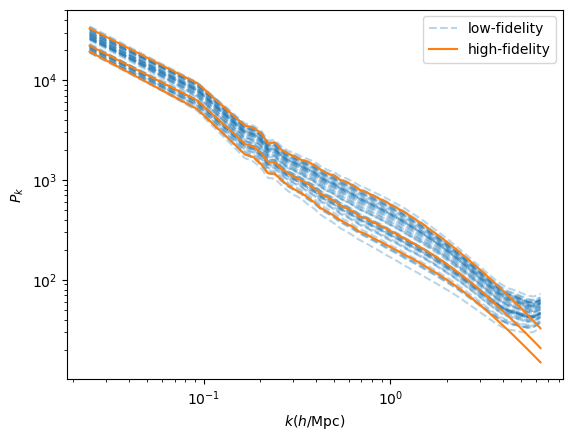

In [4]:
# visualize training spectra
for i,y_train in enumerate(data.Y_train[0]):
    if i == 0:
        plt.loglog(10**data.kf, 10**y_train, label="low-fidelity", color="C0", ls='--', alpha=0.3)
    else:
        plt.loglog(10**data.kf, 10**y_train, color="C0", ls='--', alpha=0.3)
for i,y_train in enumerate(data.Y_train[1]):
    if i == 0:
        plt.loglog(10**data.kf, 10**y_train, label="high-fidelity", color="C1")
    else:
        plt.loglog(10**data.kf, 10**y_train, color="C1")
plt.legend()
plt.xlabel(r"$k (h/\mathrm{Mpc})$")
plt.ylabel(r"$P_{k}$")


## Latent space inference : Factor analysis using the mixing matrix

In [1]:
from mfgpflow.linear_svgp import LatentMFCoregionalizationSVGP

2025-03-09 14:09:10.133512: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 14:09:10.136717: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 14:09:10.146744: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741547350.163534 2424592 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741547350.168443 2424592 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-09 14:09:10.185971: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

2025-03-09 14:09:38.405099: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


🔹 KMeans Inducing Points: [[0.78 0.63 0.2  0.64 0.11 0.  ]
 [0.17 0.33 0.81 0.23 0.69 0.  ]
 [0.25 0.61 0.57 0.93 0.81 0.  ]
 [0.77 0.29 0.51 0.19 0.43 0.  ]
 [0.55 0.65 0.83 0.79 0.65 0.  ]
 [0.29 0.51 0.87 0.83 0.47 1.  ]
 [0.79 0.17 0.35 0.85 0.63 0.  ]
 [0.11 0.95 0.17 0.71 0.45 0.  ]
 [0.09 0.63 0.01 0.21 0.09 0.  ]
 [0.53 0.09 0.11 0.39 0.79 1.  ]
 [0.21 0.89 0.65 0.03 0.25 1.  ]
 [0.65 0.71 0.09 0.69 0.91 0.  ]
 [0.45 0.49 0.71 0.41 0.29 0.  ]
 [0.13 0.39 0.69 0.91 0.35 0.  ]
 [0.71 0.55 0.91 0.53 0.37 0.  ]
 [0.53 0.09 0.11 0.39 0.79 0.  ]
 [0.99 0.05 0.89 0.37 0.13 0.  ]
 [0.61 0.15 0.43 0.99 0.11 0.  ]
 [0.03 0.21 0.55 0.07 0.23 0.  ]
 [0.43 0.86 0.6  0.61 0.42 0.  ]
 [0.87 0.77 0.47 0.33 0.93 0.  ]
 [0.05 0.97 0.33 0.29 0.49 0.  ]
 [0.31 0.93 0.37 0.89 0.77 0.  ]
 [0.21 0.89 0.65 0.03 0.25 0.  ]
 [0.33 0.59 0.99 0.45 0.85 0.  ]
 [0.91 0.35 0.79 0.73 0.83 0.  ]
 [0.89 0.47 0.03 0.95 0.03 0.  ]
 [0.59 0.01 0.39 0.09 0.61 0.  ]
 [0.85 0.75 0.63 0.49 0.21 0.  ]
 [0.19 0.19 0.45 

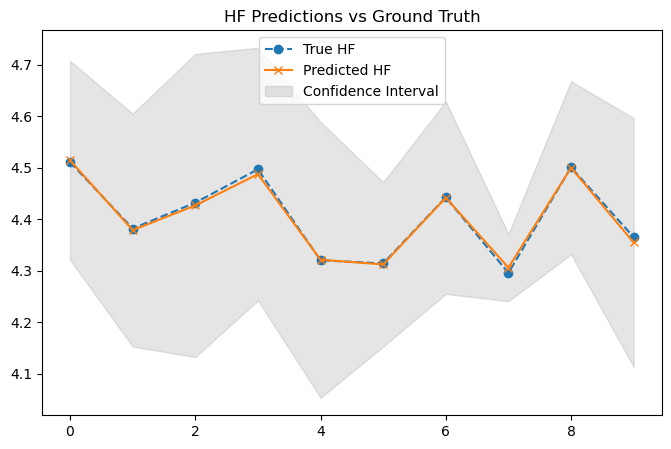

In [5]:
import numpy as np
import gpflow
import tensorflow as tf
from sklearn.cluster import KMeans

# 🔹 1️⃣ Load Data
X_LF, Y_LF = data.X_train_norm[0], data.Y_train_norm[0]  # LF Data (50, 5) → (50, 49)
X_HF, Y_HF = data.X_train_norm[1], data.Y_train_norm[1]  # HF Data (3, 5) → (3, 49)
X_test_HF, Y_test_HF = data.X_test_norm[0], data.Y_test[0]  # Test HF Data (10, 5) → (10, 49)

# 🔹 2️⃣ Prepare Training Data
n_LF, n_HF = X_LF.shape[0], X_HF.shape[0]  # Number of points
output_dim = Y_LF.shape[1]  # 49 output dimensions
num_latents = 10  # Reduce latent GPs to match HF sparsity
num_inducing = 50  # Reduce inducing points to prevent overfitting

# ✅ Append fidelity indicators (0 for LF, 1 for HF)
X_LF_aug = np.hstack([X_LF, np.zeros((n_LF, 1))])  # LF data with fidelity=0
X_HF_aug = np.hstack([X_HF, np.ones((n_HF, 1))])   # HF data with fidelity=1

# ✅ Combine datasets
X_train = np.vstack([X_LF_aug, X_HF_aug])  # Shape: (53, 6)
Y_train = np.vstack([Y_LF, Y_HF])  # Shape: (53, 49)

# 🔹 3️⃣ Define Multi-Fidelity GP Model
# ✅ Define base kernels for LF and HF discrepancy
kernel_L = gpflow.kernels.SquaredExponential(lengthscales=np.ones(5), variance=1.0)
kernel_delta = gpflow.kernels.SquaredExponential(lengthscales=np.ones(5), variance=1.0)

# ✅ Mixed Kernel (SE + Linear) to capture smooth & linear trends
kern_list = [gpflow.kernels.SquaredExponential() for _ in range(num_latents)]

# ✅ Optimize Inducing Points using K-Means Clustering
kmeans = KMeans(n_clusters=num_inducing, random_state=42).fit(X_train)
Z_init = kmeans.cluster_centers_

# ✅ Initialize the Latent Multi-Fidelity Coregionalization SVGP model
mf_gp = LatentMFCoregionalizationSVGP(
    X_train, Y_train,
    kernel_L, kernel_delta,
    num_outputs=output_dim, num_latents=num_latents, Z=Z_init
)

# 🔹 4️⃣ Train the Model with Adaptive Learning Rate
mf_gp.optimize(
    (X_train, Y_train),
    max_iters=2000,  # Reduce training iterations
    initial_lr=0.1,  # Lower learning rate for stability
    unfix_noise_after=500,  # Delay unfixing noise variance
    # decay_lr=True  # Enable learning rate decay
)

# 🔹 5️⃣ Make Predictions on HF Test Set
X_test_HF_aug = np.hstack([X_test_HF, np.ones((10, 1))])  # Add HF indicator (1)
mean_pred, var_pred = mf_gp.predict_f(X_test_HF_aug)

# 🔹 6️⃣ Compute Residuals
residuals = mean_pred.numpy() - Y_test_HF  # Shape: (10, 49)

# ✅ Print summary
print(f"🔍 Final Residuals: {residuals.mean():.4f} ± {residuals.std():.4f}")
print(f"✅ Model trained and predictions completed!")

# ✅ Check Learned W Matrix
print("🔍 Final Learned W Matrix:")
print(mf_gp.kernel.W.numpy())

# ✅ Check Noise Variance
print(f"🔍 Learned noise variance: {mf_gp.likelihood.variance.numpy()}")

# ✅ Evaluate Test Performance
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Y_test_HF, mean_pred.numpy())
print(f"🔍 HF Prediction MSE: {mse:.4f}")

# ✅ Visualize Predictions
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(Y_test_HF[:, 0], label="True HF", linestyle="--", marker="o")
plt.plot(mean_pred.numpy()[:, 0], label="Predicted HF", linestyle="-", marker="x")
plt.fill_between(
    np.arange(len(Y_test_HF[:, 0])),
    mean_pred.numpy()[:, 0] - 2 * np.sqrt(var_pred.numpy()[:, 0]),
    mean_pred.numpy()[:, 0] + 2 * np.sqrt(var_pred.numpy()[:, 0]),
    alpha=0.2, color="gray", label="Confidence Interval"
)
plt.legend()
plt.title("HF Predictions vs Ground Truth")
plt.show()

## Flattened Input:

In [1]:
import numpy as np

from matplotlib import pyplot as plt

import gpflow

import sys
sys.path.append('../')

from mfgpflow.data_loader import PowerSpecs
from mfgpflow.linear import MultiFidelityGPModel

def generate_data(folder: str = "data/50_LR_3_HR"):
    data = PowerSpecs()
    data.read_from_txt(folder=folder)
    return data

data = generate_data("../data/50_LR_3_HR")

from mfgpflow.linear_svgp import  FlattenedLatentMFCoregionalizationSVGP
import numpy as np
import gpflow
import tensorflow as tf
from sklearn.cluster import KMeans

# 🔹 1️⃣ Load Data
X_LF, Y_LF = data.X_train_norm[0], data.Y_train_norm[0]  # LF Data (50, 5) → (50, 49)
X_HF, Y_HF = data.X_train_norm[1], data.Y_train_norm[1]  # HF Data (3, 5) → (3, 49)
X_test_HF, Y_test_HF = data.X_test_norm[0], data.Y_test[0]  # Test HF Data (10, 5) → (10, 49)

# 🔹 2️⃣ Prepare Training Data
n_LF, n_HF = X_LF.shape[0], X_HF.shape[0]  # Number of points
output_dim = Y_LF.shape[1]  # 49 output dimensions
num_latents = 10  # Reduce latent GPs to match HF sparsity
num_inducing = 50  # Reduce inducing points to prevent overfitting

# ✅ Append fidelity indicators (0 for LF, 1 for HF)
X_LF_aug = np.hstack([X_LF, np.zeros((n_LF, 1))])  # LF data with fidelity=0
X_HF_aug = np.hstack([X_HF, np.ones((n_HF, 1))])   # HF data with fidelity=1
print(X_LF_aug.shape, X_HF_aug.shape)
# Repeat each element of X_LF_aug Y_LF.shape[1] times
X_LF_aug = np.repeat(X_LF_aug, Y_LF.shape[1], axis=0)
X_LF_aug = np.hstack([X_LF_aug, np.tile(np.arange(Y_LF.shape[1]), (X_LF.shape[0], 1)).flatten()[:, None]])
X_HF_aug = np.repeat(X_HF_aug, Y_HF.shape[1], axis=0)
X_HF_aug = np.hstack([X_HF_aug, np.tile(np.arange(Y_HF.shape[1]), (X_HF.shape[0], 1)).flatten()[:, None]])
print(X_LF_aug.shape, X_HF_aug.shape)
# Flatten Y values, so each row is scaler corresponding to each  (x, difelity, output_dim)
Y_LF = Y_LF.flatten()[:, None]
Y_HF = Y_HF.flatten()[:, None]

# ✅ Combine datasets
X_train = np.vstack([X_LF_aug, X_HF_aug])  # Shape: (53*49, 7)
Y_train = np.vstack([Y_LF, Y_HF])  # Shape: (53, 49)
print(f'train shape {X_train.shape} {Y_train.shape}')

# 🔹 3️⃣ Define Multi-Fidelity GP Model
# ✅ Define base kernels for LF and HF discrepancy
kernel_L = gpflow.kernels.SquaredExponential(lengthscales=np.ones(5), variance=1.0)
kernel_delta = gpflow.kernels.SquaredExponential(lengthscales=np.ones(5), variance=1.0)

# ✅ Mixed Kernel (SE + Linear) to capture smooth & linear trends
kern_list = [gpflow.kernels.SquaredExponential() for _ in range(num_latents)]

# ✅ Optimize Inducing Points using K-Means Clustering
kmeans = KMeans(n_clusters=num_inducing, random_state=42).fit(X_train)
Z_init = kmeans.cluster_centers_

# ✅ Initialize the Latent Multi-Fidelity Coregionalization SVGP model
mf_gp = FlattenedLatentMFCoregionalizationSVGP(
    X_train, Y_train,
    kernel_L, kernel_delta,
    num_outputs=output_dim, num_latents=num_latents, Z=Z_init
)

# 🔹 4️⃣ Train the Model with Adaptive Learning Rate
mf_gp.optimize(
    (X_train, Y_train),
    max_iters=2000,  # Reduce training iterations
    initial_lr=0.1,  # Lower learning rate for stability
    unfix_noise_after=500,  # Delay unfixing noise variance
    # decay_lr=True  # Enable learning rate decay
)

# 🔹 5️⃣ Make Predictions on HF Test Set
X_test_HF_aug = np.hstack([X_test_HF, np.ones((10, 1))])  # Add HF indicator (1)
X_test_HF_aug = np.repeat(X_test_HF_aug, Y_test_HF.shape[1], axis=0)
X_test_HF_aug = np.hstack([X_test_HF_aug, np.tile(np.arange(Y_test_HF.shape[1]), (X_test_HF.shape[0], 1)).flatten()[:, None]])
print(f'test shape {X_test_HF_aug.shape}')
mean_pred, var_pred = mf_gp.predict_f(X_test_HF_aug)
print(f'mean_pred: {mean_pred}')
print(f'W = {mf_gp.kernel.W}')
for i in range(num_latents):
    print(f'lengthscales = {mf_gp.kernel.base_kernels[i].kernel_L.lengthscales}')
print(f'likelihood variance = {mf_gp.likelihood.variance}')
# 🔹 6️⃣ Compute Residuals
residuals = mean_pred.numpy() - Y_test_HF.flatten()  # Shape: (10, 49)

# ✅ Print summary
print(f"🔍 Final Residuals: {residuals.mean():.4f} ± {residuals.std():.4f}")
print(f"✅ Model trained and predictions completed!")

# ✅ Check Learned W Matrix
print("🔍 Final Learned W Matrix:")
print(mf_gp.kernel.W.numpy())

# ✅ Check Noise Variance
print(f"🔍 Learned noise variance: {mf_gp.likelihood.variance.numpy()}")

# ✅ Evaluate Test Performance
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Y_test_HF.flatten(), mean_pred.numpy())
print(f"🔍 HF Prediction MSE: {mse:.4f}")

# ✅ Visualize Predictions
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(Y_test_HF[:, 0], label="True HF", linestyle="--", marker="o")
plt.plot(mean_pred.numpy()[:, 0], label="Predicted HF", linestyle="-", marker="x")
plt.fill_between(
    np.arange(len(Y_test_HF[:, 0])),
    mean_pred.numpy()[:, 0] - 2 * np.sqrt(var_pred.numpy()[:, 0]),
    mean_pred.numpy()[:, 0] + 2 * np.sqrt(var_pred.numpy()[:, 0]),
    alpha=0.2, color="gray", label="Confidence Interval"
)
plt.legend()
plt.title("HF Predictions vs Ground Truth")
plt.show()

2025-03-09 16:59:09.084442: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 16:59:09.087556: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 16:59:09.097311: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741557549.113363 2433958 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741557549.118117 2433958 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-09 16:59:09.135597: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

(50, 6) (3, 6)
(2450, 7) (147, 7)
train shape (2597, 7) (2597, 1)


2025-03-09 16:59:12.019506: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


 X shape: (2597, 7), Y shape: (2597, 1)
🔹 Optimizing...
🔹 Iteration 0: ELBO = 29167.800346000677
🔹 Iteration 100: ELBO = 25027.459658976666
🔹 Iteration 200: ELBO = 25027.439596658416
🔹 Iteration 300: ELBO = 25027.439593440988
🔹 Iteration 400: ELBO = 25027.439593440944
🔹 Unfixing noise variance at iteration 500
🔹 Iteration 500: ELBO = 25027.43959344094
🔹 Iteration 600: ELBO = 25027.439593440937
🔹 Iteration 700: ELBO = 25027.439593440937
🔹 Iteration 800: ELBO = 25027.439593440937
🔹 Iteration 900: ELBO = 25027.439593440937
🔹 Iteration 1000: ELBO = 25027.439593440937
🔹 Iteration 1100: ELBO = 25027.439593440937
🔹 Iteration 1200: ELBO = 25027.439593440937
🔹 Iteration 1300: ELBO = 25027.439593440937
🔹 Iteration 1400: ELBO = 25027.439593440937
🔹 Iteration 1500: ELBO = 25027.439593440937
🔹 Iteration 1600: ELBO = 25027.439593440937
🔹 Iteration 1700: ELBO = 25027.439593440937
🔹 Iteration 1800: ELBO = 25027.439593440937
🔹 Iteration 1900: ELBO = 25027.439593440937
test shape (490, 7)
mean_pred: [[0

ValueError: operands could not be broadcast together with shapes (490,10) (490,) 

In [2]:
mf_gp.trainable_parameters

(<Parameter: name=identity, dtype=float64, shape=[50, 10], fn="identity", numpy=
 array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0.

mf_gp.trainable_variables

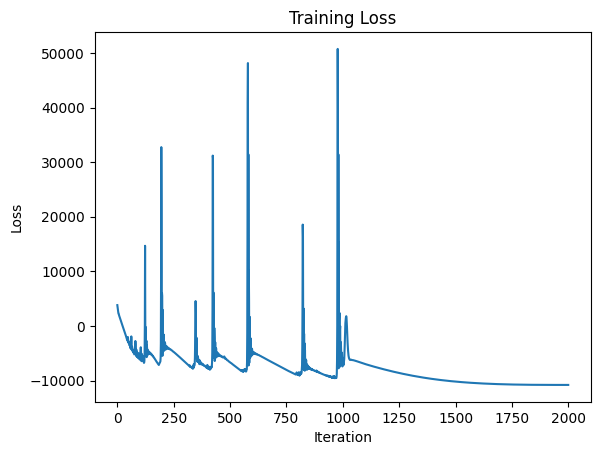

In [5]:
plt.plot(mf_gp.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

Text(0.5, 0, 'Latent Dimension')

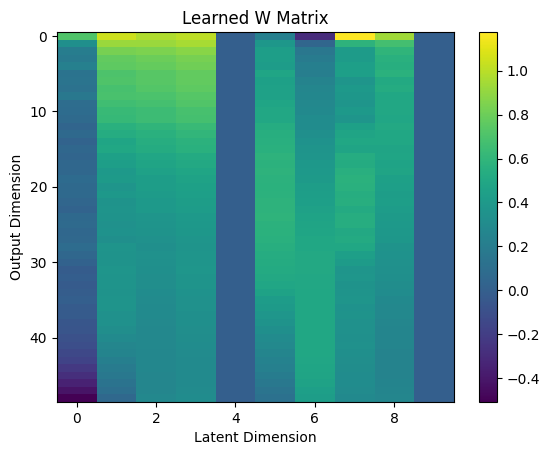

In [6]:
# plot the W matrix
plt.imshow(mf_gp.kernel.W.numpy(), aspect="auto")
plt.colorbar()
plt.title("Learned W Matrix")
plt.ylabel("Output Dimension")
plt.xlabel("Latent Dimension")

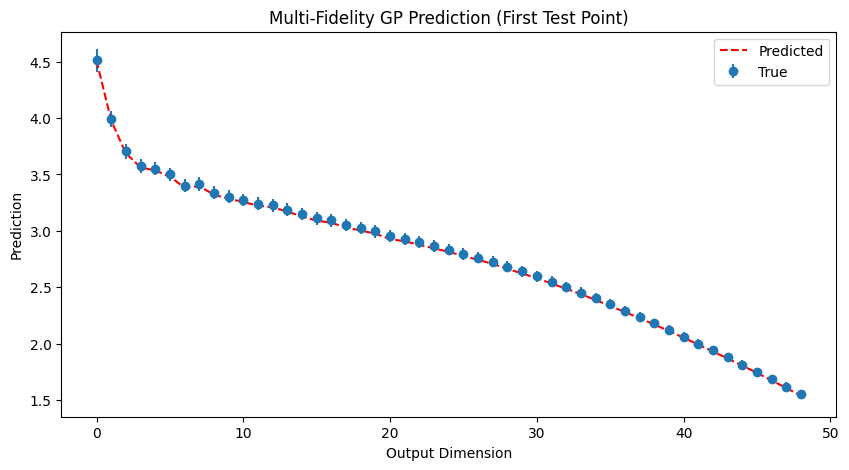

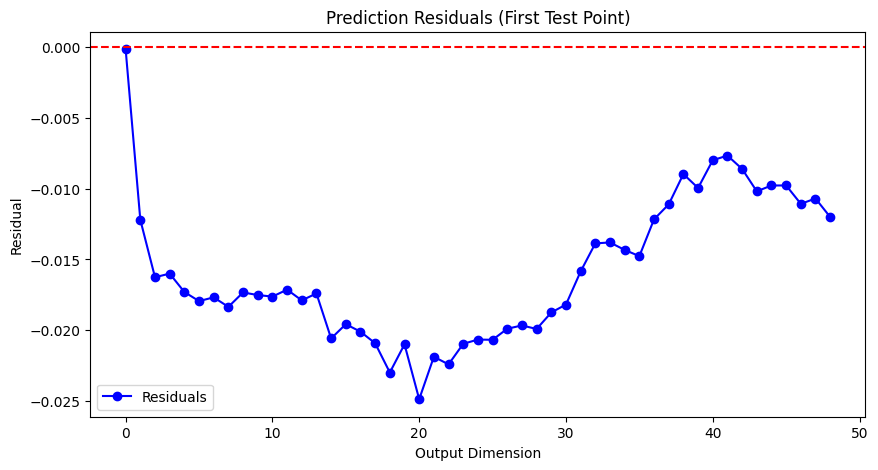

In [7]:

# 🔹 7️⃣ Plot Predictions vs Ground Truth
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.errorbar(np.arange(49), Y_test_HF[0], yerr=np.sqrt(var_pred.numpy()[0]), fmt='o', label="True")
plt.plot(np.arange(49), mean_pred.numpy()[0], 'r--', label="Predicted")
plt.xlabel("Output Dimension")
plt.ylabel("Prediction")
plt.legend()
plt.title("Multi-Fidelity GP Prediction (First Test Point)")
plt.show()

# 🔹 8️⃣ Residual Plot
plt.figure(figsize=(10, 5))
plt.plot(np.arange(49), residuals[0], 'bo-', label="Residuals")
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Output Dimension")
plt.ylabel("Residual")
plt.legend()
plt.title("Prediction Residuals (First Test Point)")
plt.show()

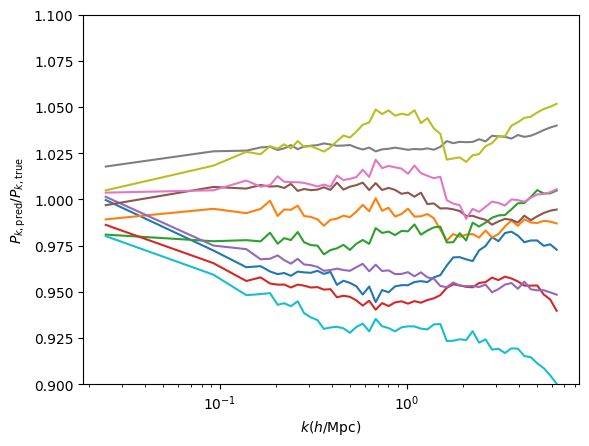

Text(0, 0.5, '$P_{k,\\mathrm{pred}}-P_{k,\\mathrm{true}}$')

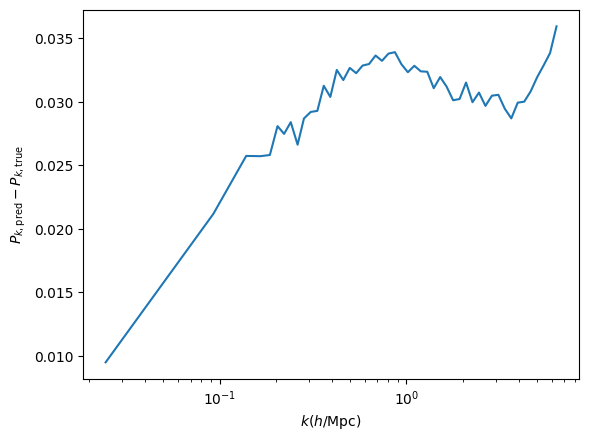

In [8]:
plt.semilogx(10**data.kf, (10**mean_pred/10**Y_test_HF).numpy().T);
plt.ylim(0.9, 1.1)
plt.xlabel(r"$k (h/\mathrm{Mpc})$")
plt.ylabel(r"$P_{k,\mathrm{pred}}/P_{k,\mathrm{true}}$")
plt.show()
# absolute error
plt.semilogx(10**data.kf, np.abs((10**mean_pred/10**Y_test_HF - 1).numpy()).mean(axis=0));
plt.xlabel(r"$k (h/\mathrm{Mpc})$")
plt.ylabel(r"$P_{k,\mathrm{pred}}-P_{k,\mathrm{true}}$")

In [9]:
for var in mf_gp.trainable_variables:
    print(var.name, var.shape)

Variable:0 (50, 10)
fill_triangular:0 (10, 1275)
Variable:0 (50, 6)
identity:0 (49, 10)
softplus:0 (1, 1)
softplus:0 (5,)
softplus:0 ()
softplus:0 (5,)
softplus:0 ()
softplus:0 (1, 1)
softplus:0 (5,)
softplus:0 ()
softplus:0 (5,)
softplus:0 ()
softplus:0 (1, 1)
softplus:0 (5,)
softplus:0 ()
softplus:0 (5,)
softplus:0 ()
softplus:0 (1, 1)
softplus:0 (5,)
softplus:0 ()
softplus:0 (5,)
softplus:0 ()
softplus:0 (1, 1)
softplus:0 (5,)
softplus:0 ()
softplus:0 (5,)
softplus:0 ()
softplus:0 (1, 1)
softplus:0 (5,)
softplus:0 ()
softplus:0 (5,)
softplus:0 ()
softplus:0 (1, 1)
softplus:0 (5,)
softplus:0 ()
softplus:0 (5,)
softplus:0 ()
softplus:0 (1, 1)
softplus:0 (5,)
softplus:0 ()
softplus:0 (5,)
softplus:0 ()
softplus:0 (1, 1)
softplus:0 (5,)
softplus:0 ()
softplus:0 (5,)
softplus:0 ()
softplus:0 (1, 1)
softplus:0 (5,)
softplus:0 ()
softplus:0 (5,)
softplus:0 ()
chain_of_shift_of_softplus:0 ()


In [10]:
mf_gp

name,class,transform,prior,trainable,shape,dtype,value
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_L.variance,Parameter,Softplus,,True,(),float64,2e-05
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_L.lengthscales,Parameter,Softplus,,True,"(5,)",float64,"[4.66225, 3.96527, 7.00349..."
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_delta.variance,Parameter,Softplus,,True,(),float64,0.36524
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_delta.lengthscales,Parameter,Softplus,,True,"(5,)",float64,"[6.21407, 6.73792, 6.01032..."
LatentMFCoregionalizationSVGP.kernel.kernels[0].rho,Parameter,Softplus,,True,"(1, 1)",float64,[[0.31284]]
LatentMFCoregionalizationSVGP.kernel.kernels[1].kernel_L.variance,Parameter,Softplus,,True,(),float64,0.0
LatentMFCoregionalizationSVGP.kernel.kernels[1].kernel_L.lengthscales,Parameter,Softplus,,True,"(5,)",float64,"[4.99199, 5.73224, 6.84447..."
LatentMFCoregionalizationSVGP.kernel.kernels[1].kernel_delta.variance,Parameter,Softplus,,True,(),float64,0.7159
LatentMFCoregionalizationSVGP.kernel.kernels[1].kernel_delta.lengthscales,Parameter,Softplus,,True,"(5,)",float64,"[16.88034, 9.87217, 9.35954..."
LatentMFCoregionalizationSVGP.kernel.kernels[1].rho,Parameter,Softplus,,True,"(1, 1)",float64,[[0.25118]]
